In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib


In [2]:
df = pd.read_csv("yield_df.csv")
df = df[['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp', 'hg/ha_yield']]
df.head()


,Area,Item,Year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,hg/ha_yield
0,Albania,Maize,1990,1485.0,121.0,16.37,36613
1,Albania,Potatoes,1990,1485.0,121.0,16.37,66667
2,Albania,"Rice, paddy",1990,1485.0,121.0,16.37,23333
3,Albania,Sorghum,1990,1485.0,121.0,16.37,12500
4,Albania,Soybeans,1990,1485.0,121.0,16.37,7000


In [3]:
X = df[['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']]
y = df['hg/ha_yield'] / 10000


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_encoder', OneHotEncoder(handle_unknown='ignore'), ['Area', 'Item'])
    ],
    remainder='passthrough'
)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [6]:
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', model)
])

pipeline.fit(X_train, y_train)


/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Area', 'Item'])])),
                ('model',
                 RandomForestRegressor(max_depth=15, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

In [7]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (t/ha):", round(mae, 4))
print("Root Mean Squared Error (t/ha):", round(rmse, 4))
print("R² Score:", round(r2, 4))


Mean Absolute Error (t/ha): 0.6272
Root Mean Squared Error (t/ha): 1.2477
R² Score: 0.9785


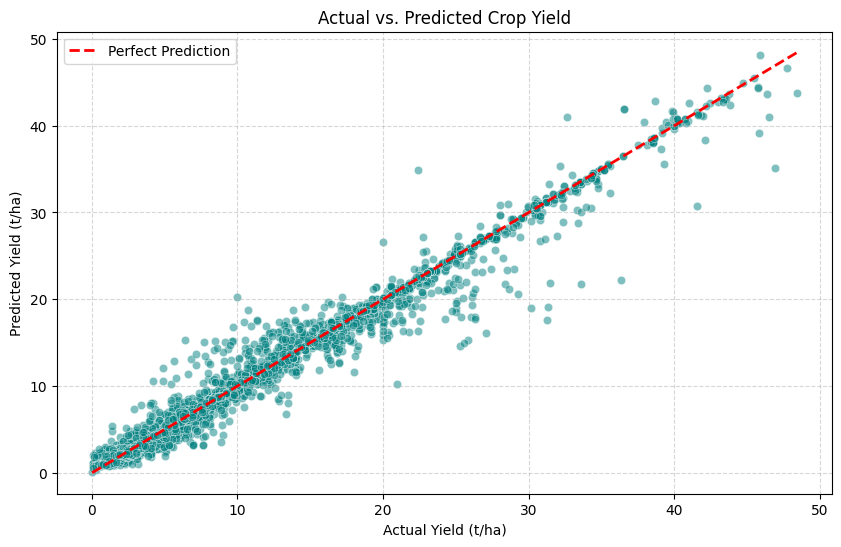

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Yield (t/ha)")
plt.ylabel("Predicted Yield (t/ha)")
plt.title("Actual vs. Predicted Crop Yield")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


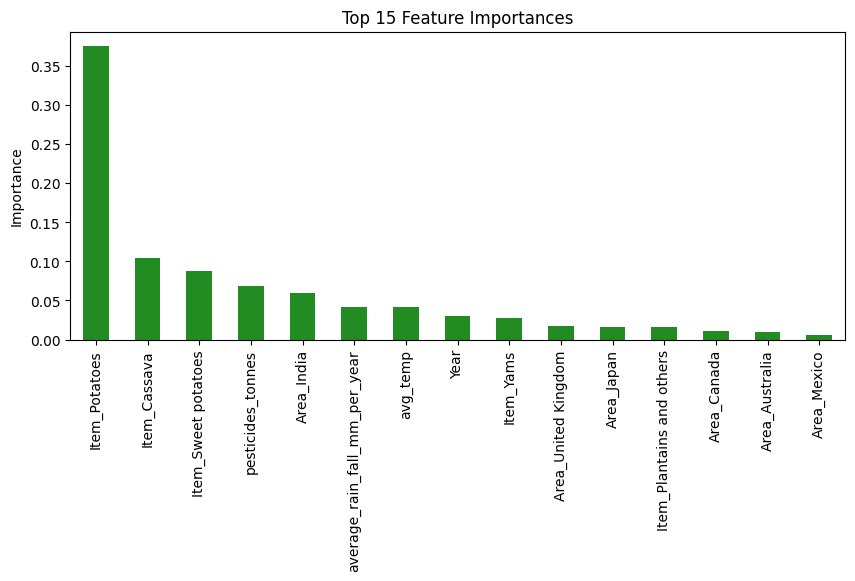

In [9]:
rf_model = pipeline.named_steps['model']
cat_encoder = pipeline.named_steps['preprocess'].named_transformers_['cat_encoder']
cat_features = list(cat_encoder.get_feature_names_out(['Area', 'Item']))
num_features = ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
feature_names = cat_features + num_features

importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

importance.plot(kind='bar', figsize=(10, 4), color='forestgreen', title="Top 15 Feature Importances")
plt.ylabel("Importance")
plt.show()


In [10]:
pipeline_bundle = {
    'pipeline': pipeline,
    'model': model,
    'preprocessor': preprocessor
}

joblib.dump(pipeline, 'yield_model.joblib', compress=3)


['yield_model.joblib']